In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
input_df = pd.read_csv('sales_data.csv')
input_df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
input_df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [4]:
input_df['Category'].unique()

array(['Electronics', 'Clothing', 'Groceries', 'Toys', 'Furniture'],
      dtype=object)

In [5]:
print(input_df['Date'].min())
print(input_df['Date'].max())

2022-01-01
2024-01-30


In [6]:
# Sort the entire dataframe by date
# Convert Date
input_df['Date'] = pd.to_datetime(input_df['Date'])
input_df = input_df.sort_values(by='Date')
input_df.shape

(76000, 16)

In [7]:
# -------------------------------
# 2. Aggregate to Department Level
# -------------------------------
agg_dict = {
    'Demand': 'sum',
    'Units Sold': 'sum',
    'Units Ordered': 'sum',
    'Inventory Level': 'mean',
    'Price': 'mean',
    'Discount': 'mean',
    'Competitor Pricing': 'mean'
}

df_agg = input_df.groupby(['Date', 'Category']).agg(agg_dict).reset_index()
df_agg.shape

(3800, 9)

In [8]:
# -------------------------------
# 3. Feature Engineering
# -------------------------------
# Time features
df_agg['month'] = df_agg['Date'].dt.month
df_agg['dayofweek'] = df_agg['Date'].dt.dayofweek

# Lag features
df_agg = df_agg.sort_values(['Category', 'Date'])
df_agg['lag_7'] = df_agg.groupby('Category')['Demand'].shift(7)
df_agg['lag_14'] = df_agg.groupby('Category')['Demand'].shift(14)

# Drop NA from lagging
df_agg = df_agg.dropna()

In [9]:
# -------------------------------
# 4. Log Transformation
# -------------------------------
log_cols = ['Demand', 'Price', 'Discount', 'Inventory Level',
            'Units Sold', 'Units Ordered', 'Competitor Pricing',
            'lag_7', 'lag_14']

for col in log_cols:
    df_agg[f'log_{col}'] = np.log1p(df_agg[col])

In [10]:
# -------------------------------
# 5. Train-Test Split
# -------------------------------
train = df_agg[df_agg['Date'] <= '2023-11-30']
test = df_agg[df_agg['Date'] > '2023-11-30']

features = [
    'log_Price', 'log_Discount', 'log_Inventory Level',
    'log_Units Sold', 'log_Units Ordered',
    'log_Competitor Pricing', 'log_lag_7', 'log_lag_14',
    'month', 'dayofweek'
]

target = 'log_Demand'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [11]:
# -------------------------------
# 6. Log-Log OLS Regression
# -------------------------------
import statsmodels.api as sm

# Add intercept explicitly
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Fit OLS
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Model summary (THIS gives slope, intercept, p-values)
print(ols_model.summary())

# Predictions
ols_pred_log = ols_model.predict(X_test_sm)
ols_pred = np.expm1(ols_pred_log)


                            OLS Regression Results                            
Dep. Variable:             log_Demand   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 3.276e+04
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:06:14   Log-Likelihood:                 4600.8
No. Observations:                3425   AIC:                            -9180.
Df Residuals:                    3414   BIC:                            -9112.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [12]:
# -------------------------------
# 7. Bayesian Regression
# -------------------------------
from sklearn.linear_model import BayesianRidge


bayes_model = BayesianRidge()
bayes_model.fit(X_train, y_train)

bayes_pred_log = bayes_model.predict(X_test)
bayes_pred = np.expm1(bayes_pred_log)

In [13]:
# -------------------------------
# 8. Evaluation
# -------------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error


y_test_actual = np.expm1(y_test)

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name} Performance:")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("WAPE:", wape(y_true, y_pred))

evaluate(y_test_actual, ols_pred, "OLS Log-Log")
evaluate(y_test_actual, bayes_pred, "Bayesian Ridge")


OLS Log-Log Performance:
MAE: 94.52081588983299
RMSE: 128.9651967976702
WAPE: 0.04645708123529374

Bayesian Ridge Performance:
MAE: 94.51420445775877
RMSE: 128.953004226064
WAPE: 0.04645383170941881


In [14]:
# -------------------------------
# 9. Save Predictions
# -------------------------------
test['OLS_Prediction'] = ols_pred
test['Bayesian_Prediction'] = bayes_pred

test = test[['Date', 'Category', 'OLS_Prediction', 'Bayesian_Prediction']]
test['Actual_Demand'] = np.expm1(y_test)

test.head()

C:\Users\Genesis\AppData\Local\Temp\ipykernel_20436\3556765403.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['OLS_Prediction'] = ols_pred
C:\Users\Genesis\AppData\Local\Temp\ipykernel_20436\3556765403.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Bayesian_Prediction'] = bayes_pred


,Date,Category,OLS_Prediction,Bayesian_Prediction,Actual_Demand
3495,2023-12-01,Clothing,2039.247234,2039.249540,2128.0
3500,2023-12-02,Clothing,2077.016909,2076.920829,2204.0
3505,2023-12-03,Clothing,2017.629343,2017.598105,1915.0
3510,2023-12-04,Clothing,1658.861554,1658.920541,1911.0
3515,2023-12-05,Clothing,2224.773114,2224.667376,2393.0


In [15]:
# -------------------------------
# Train Predictions
# -------------------------------
ols_train_pred_log = ols_model.predict(X_train_sm)
ols_train_pred = np.expm1(ols_train_pred_log)

bayes_train_pred_log = bayes_model.predict(X_train)
bayes_train_pred = np.expm1(bayes_train_pred_log)

# -------------------------------
# Test Predictions (already done)
# -------------------------------
ols_test_pred = ols_pred
bayes_test_pred = bayes_pred

# -------------------------------
# Combine Train + Test
# -------------------------------
train['OLS_Prediction'] = ols_train_pred
train['Bayesian_Prediction'] = bayes_train_pred
train['Actual_Demand'] = np.expm1(y_train)

test['OLS_Prediction'] = ols_test_pred
test['Bayesian_Prediction'] = bayes_test_pred
test['Actual_Demand'] = np.expm1(y_test)

# Merge full dataset
full_df = pd.concat([train, test]).sort_values('Date')

C:\Users\Genesis\AppData\Local\Temp\ipykernel_20436\1302269780.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['OLS_Prediction'] = ols_train_pred
C:\Users\Genesis\AppData\Local\Temp\ipykernel_20436\1302269780.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Bayesian_Prediction'] = bayes_train_pred
C:\Users\Genesis\AppData\Local\Temp\ipykernel_20436\1302269780.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

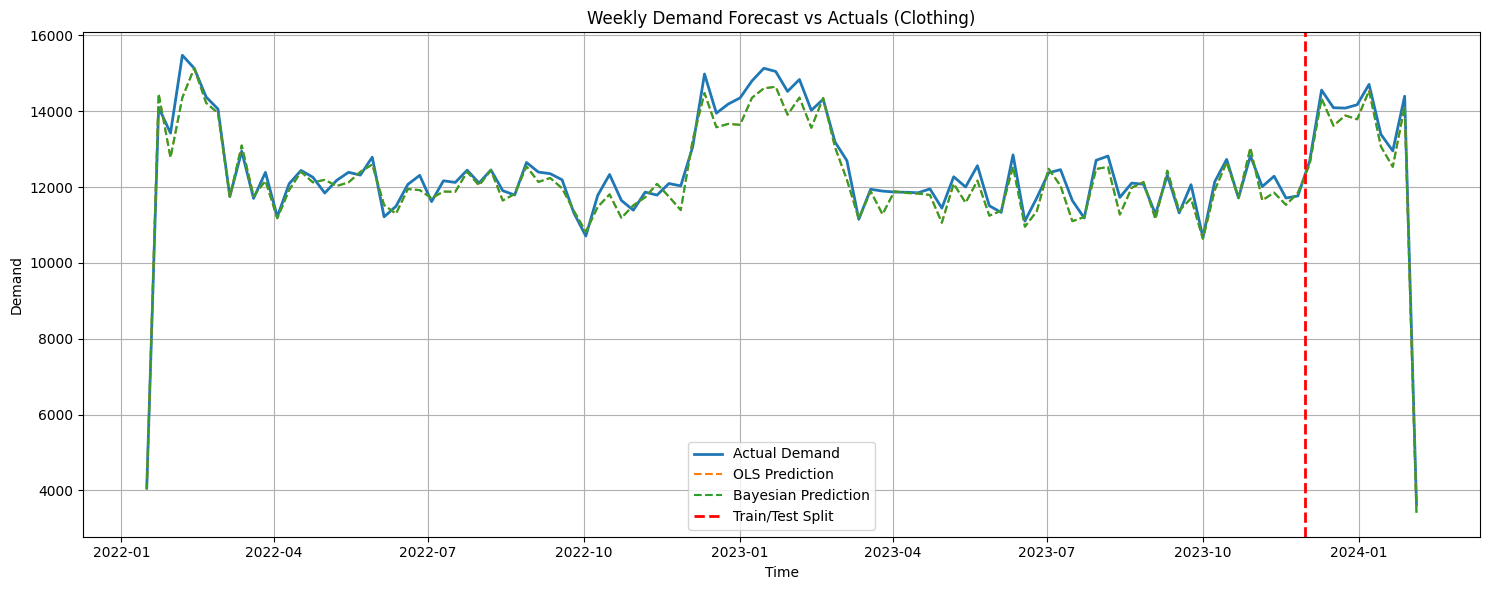

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_weekly_forecast_full(df, category_name, split_date="2023-11-30"):
    """
    Plots weekly actual vs predicted demand (train + test) for a given category
    """

    # -------------------------------
    # 1. Filter category
    # -------------------------------
    df_cat = df[df['Category'] == category_name].copy()

    if df_cat.empty:
        print(f"No data found for category: {category_name}")
        return

    df_cat['Date'] = pd.to_datetime(df_cat['Date'])

    # -------------------------------
    # 2. Weekly aggregation
    # -------------------------------
    weekly_df = df_cat.set_index('Date').resample('W').agg({
        'Actual_Demand': 'sum',
        'OLS_Prediction': 'sum',
        'Bayesian_Prediction': 'sum'
    }).reset_index()

    # -------------------------------
    # 3. Plot
    # -------------------------------
    plt.figure(figsize=(15, 6))

    plt.plot(weekly_df['Date'], weekly_df['Actual_Demand'], 
             label='Actual Demand', linewidth=2)

    plt.plot(weekly_df['Date'], weekly_df['OLS_Prediction'], 
             label='OLS Prediction', linestyle='--')

    plt.plot(weekly_df['Date'], weekly_df['Bayesian_Prediction'], 
             label='Bayesian Prediction', linestyle='--')

    # Train/Test split line
    plt.axvline(pd.to_datetime(split_date), 
                color='red', linestyle='--', linewidth=2, label='Train/Test Split')

    plt.title(f"Weekly Demand Forecast vs Actuals ({category_name})")
    plt.xlabel("Time")
    plt.ylabel("Demand")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_weekly_forecast_full(full_df, "Clothing") #'Electronics', 'Groceries', 'Clothing', 'Furniture', 'Toys']

## MLFlow Setup

In [42]:
import mlflow

mlflow.set_experiment("Retail_Demand_Forecasting")

2026/04/25 21:10:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/25 21:10:31 INFO mlflow.store.db.utils: Updating database tables
2026/04/25 21:10:33 INFO mlflow.tracking.fluent: Experiment with name 'Retail_Demand_Forecasting' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/Genesis/OneDrive/Desktop/Projects/Retail-Price-Optimization/mlruns/1', creation_time=1777131633766, experiment_id='1', last_update_time=1777131633766, lifecycle_stage='active', name='Retail_Demand_Forecasting', tags={}, trace_location=None, workspace='default'>

In [43]:
import mlflow
import mlflow.sklearn
import mlflow.statsmodels

with mlflow.start_run(run_name="Baseline_LogLog_Models"):

    # -------------------------------
    # Log parameters
    # -------------------------------
    mlflow.log_param("model_type", "OLS + Bayesian")
    mlflow.log_param("features", str(features))
    mlflow.log_param("train_end_date", "2023-11-30")

    # -------------------------------
    # Log metrics
    # -------------------------------
    mlflow.log_metric("OLS_WAPE", wape(y_test_actual, ols_pred))
    mlflow.log_metric("OLS_RMSE", np.sqrt(mean_squared_error(y_test_actual, ols_pred)))

    mlflow.log_metric("Bayesian_WAPE", wape(y_test_actual, bayes_pred))
    mlflow.log_metric("Bayesian_RMSE", np.sqrt(mean_squared_error(y_test_actual, bayes_pred)))

    # -------------------------------
    # Log models
    # -------------------------------
    mlflow.statsmodels.log_model(ols_model, "ols_model")

    mlflow.sklearn.log_model(bayes_model, "bayesian_model")

    # -------------------------------
    # Save artifact (predictions)
    # -------------------------------
    full_df.to_csv("forecast_output.csv", index=False)
    mlflow.log_artifact("forecast_output.csv")

2026/04/25 21:11:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 21:12:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 21:12:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
